# B05 · SciPy 科学计算与数值模拟（重点课）

> 阶段〇第 5 周，本阶段**最核心**的一周。
> B01 里我们手写欧拉法仿真一阶环节；本周升级为专业工具 `scipy.integrate.solve_ivp`，
> 把「微分方程 → 数值解」这条路彻底走通，再补上插值与拟合。
> 这套能力在阶段四（Isaac/MuJoCo 仿真）之前，是你理解「物理仿真器在干什么」的钥匙。

## 学习目标

1. 用 `solve_ivp` 求解 ODE：会写**状态导数函数**、设时间区间与初值、取结果；
2. 求解一阶惯性环节阶跃响应并**对照解析解**验证精度；
3. 理解 `rtol/atol`（相对/绝对误差容限）与自适应步长的概念，知道 `t_eval` 的作用；
4. 把二阶系统（弹簧阻尼、RLC）写成状态空间形式求解，对比不同阻尼；
5. 对比单摆的**非线性模型 vs 小角度线性化**，量化线性化适用范围；
6. 用 `scipy.interpolate` 插值、`scipy.optimize.curve_fit` 做参数拟合（系统辨识的萌芽）；
7. 知道「刚性（stiff）」是什么、遇到时换什么求解器（点到为止）。

## 1. `solve_ivp` 的心智模型

求解**初值问题** $\dot{y} = f(t, y),\ y(t_0) = y_0$，你只需要提供三件事：

1. **导数函数** `f(t, y)`：给定当前时刻和状态，返回状态的导数；
2. **时间区间** `(t0, tf)` 与**初值** `y0`；
3. （可选）`t_eval`：想要哪些时刻的输出；不设则只给求解器自适应选点的结果。

求解器内部自动选择步长（自适应 Runge-Kutta，默认 `RK45`），
在误差容限 `rtol/atol` 内保证精度——比你手写的定步长欧拉法又准又省心。

$$\text{你写 } f \quad\longrightarrow\quad \texttt{solve\_ivp} \text{ 负责积分} \quad\longrightarrow\quad \text{得到 } y(t)$$

## 2. 一阶惯性环节：与解析解对照

一阶环节 $\tau\dot{y} + y = Ku$，阶跃输入 $u=1$ 的解析解 $y(t) = K(1-e^{-t/\tau})$。
先用 `solve_ivp` 数值求解，再和解析解比误差——**有解析解的问题是验证数值方法的黄金标准**。

In [1]:
import numpy as np
from scipy.integrate import solve_ivp

K, tau = 2.0, 0.5

def first_order(t, y):
    '''一阶惯性环节：dy/dt = (K*u - y)/tau，u 为单位阶跃。'''
    u = 1.0
    return [(K * u - y[0]) / tau]

t_eval = np.linspace(0, 3, 301)
sol = solve_ivp(first_order, (0, 3), [0.0], t_eval=t_eval, rtol=1e-8, atol=1e-10)

print("sol 的字段:", sol.keys())
print("sol.t shape:", sol.t.shape, "| sol.y shape:", sol.y.shape)  # y 是 (状态数, 时间点数)
print("求解成功?", sol.success)

# 与解析解对照
y_exact = K * (1 - np.exp(-sol.t / tau))
err = np.abs(sol.y[0] - y_exact)
print(f"最大绝对误差: {err.max():.2e}  （容限 rtol=1e-8 下精度极高）")

sol 的字段: dict_keys(['t', 'y', 'sol', 't_events', 'y_events', 'nfev', 'njev', 'nlu', 'status', 'message', 'success'])
sol.t shape: (301,) | sol.y shape: (1, 301)
求解成功? True
最大绝对误差: 3.81e-09  （容限 rtol=1e-8 下精度极高）


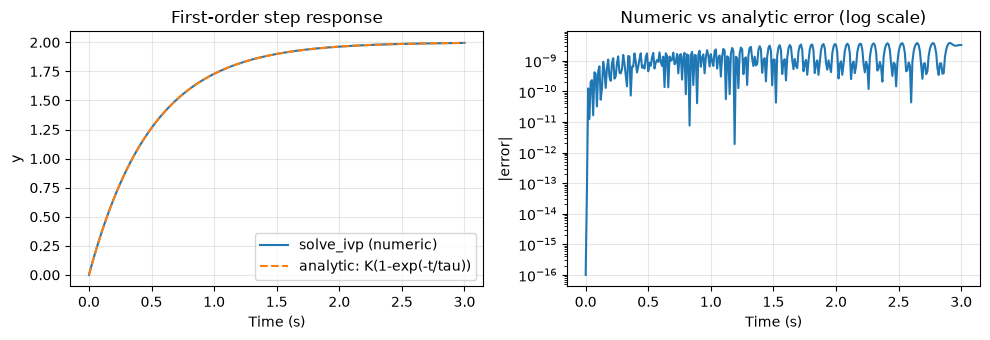

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(sol.t, sol.y[0], label="solve_ivp (numeric)")
axes[0].plot(sol.t, y_exact, "--", label="analytic: K(1-exp(-t/tau))")
axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("y")
axes[0].set_title("First-order step response"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].semilogy(sol.t, err + 1e-16)
axes[1].set_xlabel("Time (s)"); axes[1].set_ylabel("|error|")
axes[1].set_title("Numeric vs analytic error (log scale)"); axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

**两条曲线肉眼完全重合**——右图对数坐标下的误差在 $10^{-9}$ 量级。
这就是 `rtol=1e-8`（相对误差容限）的含义：求解器自动调节步长，保证每步误差相对量级不超过它。

### 2.1 容限与步长的直觉（点到为止）

- **自适应步长**：曲线平缓时求解器大步走，变化剧烈时自动小步加密——
  所以 `sol.t`（不给 `t_eval` 时）的点是不均匀的；
- `rtol` / `atol`：**相对** / **绝对**误差容限。物理量接近 0 时相对误差没意义，靠 `atol` 兜底；
  工程仿真常用 `rtol=1e-6` 量级，追求高精度再收紧；
- `t_eval` 只是「**输出**在哪些时刻取值」，不影响内部步长——
  想要光滑曲线就多给点，想要内部细节就用 `dense_output=True` 得到连续插值函数。

In [3]:
# 不给 t_eval：看求解器自己选的步长分布
sol_free = solve_ivp(first_order, (0, 3), [0.0], rtol=1e-6, atol=1e-9)
print("自适应取点数:", len(sol_free.t))
print("前 10 个内部步长:", np.round(np.diff(sol_free.t)[:10], 4))
# 响应初期变化快 → 步长小；接近稳态 → 步长大。这就是「自适应」。

自适应取点数: 23
前 10 个内部步长: [1.000e-04 1.000e-03 1.000e-02 5.510e-02 7.740e-02 9.070e-02 1.012e-01
 1.105e-01 1.193e-01 1.280e-01]


## 3. 二阶系统 I：弹簧-质量-阻尼

$m\ddot{x} + c\dot{x} + kx = F$。高阶 ODE 的标准处理：**引进状态向量降成一阶**。

取状态 $\boldsymbol{s} = [x,\ \dot{x}]^T$，则

$$\frac{d}{dt}\begin{bmatrix} x \\ \dot{x} \end{bmatrix} = \begin{bmatrix} \dot{x} \\ (F - c\dot{x} - kx)/m \end{bmatrix}$$

对比三种阻尼（$m=1,\ k=4$，固有频率 $\omega_n = \sqrt{k/m} = 2$ rad/s）：欠阻尼、临界阻尼、过阻尼。

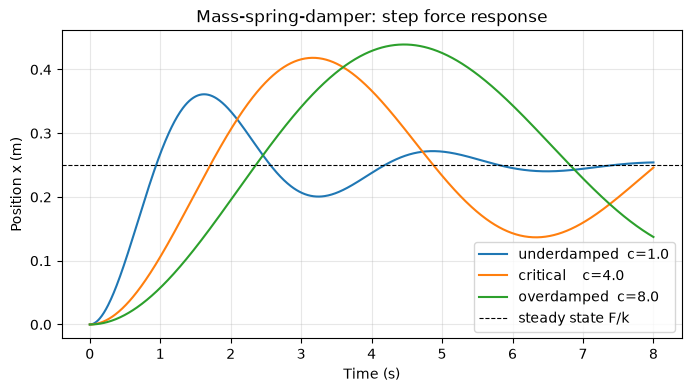

In [4]:
def spring_damper(t, s, m=1.0, c=1.0, k=4.0, F=1.0):
    '''弹簧-质量-阻尼：s = [位置 x, 速度 v]，阶跃力 F 输入。'''
    x, v = s
    return [v, (F - c * v - k * x) / m]

m, k = 1.0, 4.0
c_crit = 2 * np.sqrt(k * m)          # 临界阻尼系数 c = 2√(km)
cases = [("underdamped  c=1.0", 1.0), ("critical    c=4.0", c_crit), ("overdamped  c=8.0", 8.0)]

fig, ax = plt.subplots(figsize=(8, 4))
t_eval = np.linspace(0, 8, 800)
for label, c in cases:
    sol = solve_ivp(spring_damper, (0, 8), [0.0, 0.0], args=(c,),
                    t_eval=t_eval, rtol=1e-8, atol=1e-10)
    ax.plot(sol.t, sol.y[0], label=label)

ax.axhline(1 / k, ls="--", color="k", lw=0.8, label="steady state F/k")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Position x (m)")
ax.set_title("Mass-spring-damper: step force response")
ax.legend(); ax.grid(alpha=0.3)
plt.show()
# 观察：欠阻尼有超调和振荡；临界阻尼最快无超调；过阻尼缓慢爬升。稳态值均为 F/k = 0.25。

## 4. 二阶系统 II：RLC 串联电路（机电对偶）

串联 RLC：$L\ddot{q} + R\dot{q} + q/C = u(t)$，$q$ 为电容电荷（电流 $i = \dot{q}$）。

| 机械系统 | 电路系统 |
|---------|---------|
| 位移 $x$ | 电荷 $q$ |
| 质量 $m$ | 电感 $L$ |
| 阻尼 $c$ | 电阻 $R$ |
| 刚度 $k$ | $1/C$ |
| 力 $F$ | 电压 $u$ |

**同一套数学，两种物理**——写好一个求解函数，换个参数就是另一个领域。

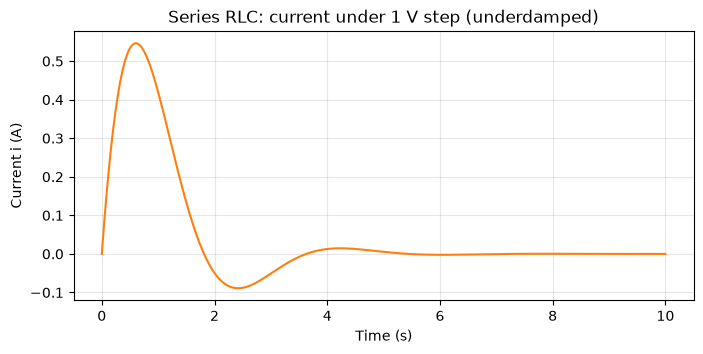

稳态电流: -0.0001 A（直流下电容开路，稳态电流→0，符合物理直觉）


In [5]:
def rlc(t, s, R=1.0, L=0.5, C=0.5, u=1.0):
    '''串联 RLC：s = [电荷 q, 电流 i]，阶跃电压 u 输入。'''
    q, i = s
    return [i, (u - R * i - q / C) / L]

# R=1, L=0.5, C=0.5 → 对照机械: m=0.5, c=1, k=2 → 欠阻尼
sol = solve_ivp(rlc, (0, 10), [0.0, 0.0], t_eval=np.linspace(0, 10, 1000),
                rtol=1e-8, atol=1e-10)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(sol.t, sol.y[1], color="tab:orange")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Current i (A)")
ax.set_title("Series RLC: current under 1 V step (underdamped)")
ax.grid(alpha=0.3)
plt.show()
print("稳态电流:", round(sol.y[1][-1], 4), "A（直流下电容开路，稳态电流→0，符合物理直觉）")

## 5. 单摆：非线性 vs 小角度线性化

单摆方程（无阻尼）：$\ddot{\theta} = -\dfrac{g}{L}\sin\theta$。

课本的小角度近似 $\sin\theta \approx \theta$ 给出线性系统
$\ddot{\theta} = -\frac{g}{L}\theta$（周期 $T_0 = 2\pi\sqrt{L/g}$）。
**近似在多大摆角下失效？** 数值仿真可以精确回答。

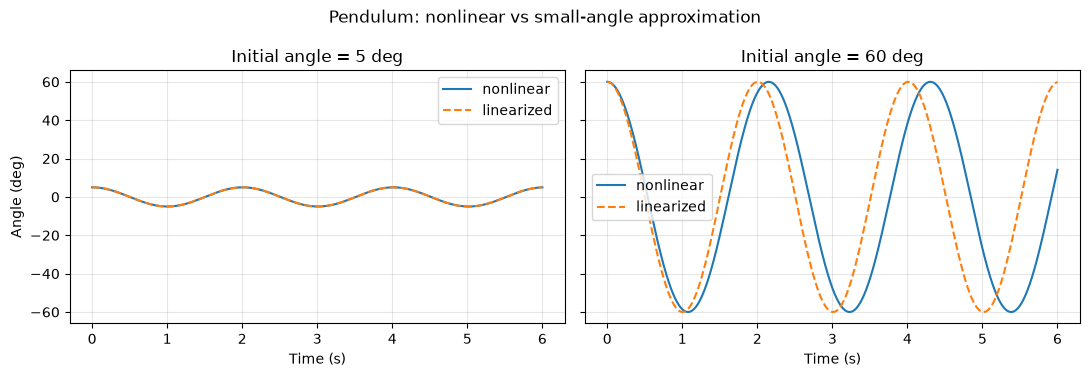

线性化周期 T0 = 2.006 s（与摆角无关）
5 deg: 两模型几乎重合 —— 线性化可用
60 deg: 非线性周期明显变长 —— 线性化失效，误差随摆角增大


In [6]:
g, L = 9.81, 1.0

def pendulum_nl(t, s):
    '''非线性单摆：s = [角度 theta, 角速度 omega]。'''
    th, om = s
    return [om, -g / L * np.sin(th)]

def pendulum_lin(t, s):
    '''线性化单摆（小角度近似 sin(theta)≈theta）。'''
    th, om = s
    return [om, -g / L * th]

t_eval = np.linspace(0, 6, 2000)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)

for ax, deg0 in zip(axes, [5, 60]):
    th0 = np.deg2rad(deg0)
    s_nl = solve_ivp(pendulum_nl, (0, 6), [th0, 0.0], t_eval=t_eval, rtol=1e-9, atol=1e-12)
    s_lin = solve_ivp(pendulum_lin, (0, 6), [th0, 0.0], t_eval=t_eval, rtol=1e-9, atol=1e-12)
    ax.plot(s_nl.t, np.rad2deg(s_nl.y[0]), label="nonlinear")
    ax.plot(s_lin.t, np.rad2deg(s_lin.y[0]), "--", label="linearized")
    ax.set_title(f"Initial angle = {deg0} deg")
    ax.set_xlabel("Time (s)"); ax.legend(); ax.grid(alpha=0.3)

axes[0].set_ylabel("Angle (deg)")
fig.suptitle("Pendulum: nonlinear vs small-angle approximation")
fig.tight_layout()
plt.show()

T0 = 2 * np.pi * np.sqrt(L / g)
print(f"线性化周期 T0 = {T0:.3f} s（与摆角无关）")
print("5 deg: 两模型几乎重合 —— 线性化可用")
print("60 deg: 非线性周期明显变长 —— 线性化失效，误差随摆角增大")

**结论**：$5°$ 时两者难分彼此；$60°$ 时非线性摆周期明显变长（大摆角 $\sin\theta < \theta$，恢复力矩变小）。
「什么时候可以线性化」不再是一句经验之谈，而是你亲手量出来的数——
这在 RL 里对应「什么时候可以用线性策略/线性化模型」的判断。

## 6. 刚性方程（stiff）：点到为止

有些系统的状态分量变化速度相差悬殊（快分量 + 慢分量，如电力电子 + 机械惯量），
称为**刚性系统**。默认的显式求解器 `RK45` 会被迫用极小步长，慢得离谱甚至失败。
对策一句话：**换隐式求解器** `method="Radau"` 或 `method="BDF"`。

判断信号：`solve_ivp` 跑了很久、`sol.nfev`（函数评估次数）异常大、或报错步长过小。
本课程不会深究，记住「慢得反常 → 想到 stiff → 换 Radau」即可。

In [7]:
# 一个温和的体验：vander Pol 振荡器在 mu 大时是经典 stiff 例子
# mu=1（非 stiff）RK45 轻松解决；mu 上千时就必须用 Radau。这里只演示用法：
from scipy.integrate import solve_ivp

def vanderpol(t, s, mu=1.0):
    x, v = s
    return [v, mu * (1 - x ** 2) * v - x]

sol = solve_ivp(vanderpol, (0, 20), [2.0, 0.0], args=(1.0,),
                t_eval=np.linspace(0, 20, 1000))
print(f"mu=1, RK45: nfev = {sol.nfev}")
# 若改成 mu=1000 并保持 RK45，nfev 会爆炸式增长；
# 这时 method="Radau" 几百次评估就能解决 —— 有兴趣可自行验证（不必做）。

mu=1, RK45: nfev = 434


## 7. 插值：`scipy.interpolate`

仿真/采样的数据是离散点，需要任意时刻的值时就靠插值。
对比**线性插值**（`interp1d`）与**三次样条**（`CubicSpline`）——
样条光滑（一阶二阶导数连续），适合轨迹生成；线性简单稳健，不会过冲。

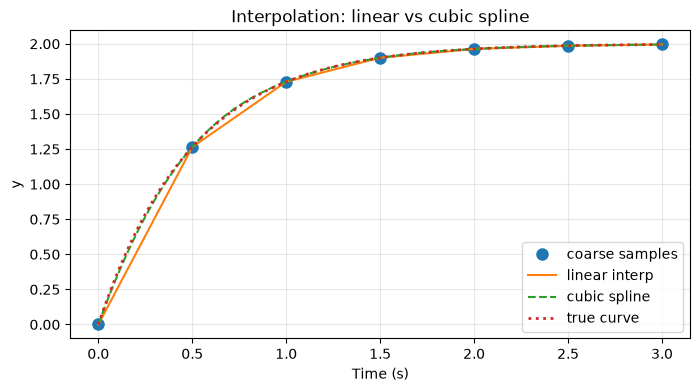

线性插值最大误差: 0.1559
样条插值最大误差: 0.02075


In [8]:
from scipy.interpolate import interp1d, CubicSpline

# 粗采样：一阶环节每 0.5 s 采一个点
t_coarse = np.arange(0, 3.01, 0.5)
y_coarse = 2 * (1 - np.exp(-t_coarse / 0.5))

f_linear = interp1d(t_coarse, y_coarse, kind="linear")
f_cubic = CubicSpline(t_coarse, y_coarse)

t_fine = np.linspace(0, 3, 301)
y_true = 2 * (1 - np.exp(-t_fine / 0.5))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_coarse, y_coarse, "o", ms=8, label="coarse samples")
ax.plot(t_fine, f_linear(t_fine), label="linear interp")
ax.plot(t_fine, f_cubic(t_fine), "--", label="cubic spline")
ax.plot(t_fine, y_true, ":", lw=2, label="true curve")
ax.set_xlabel("Time (s)"); ax.set_ylabel("y"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Interpolation: linear vs cubic spline")
plt.show()

print("线性插值最大误差:", round(np.abs(f_linear(t_fine) - y_true).max(), 4))
print("样条插值最大误差:", round(np.abs(f_cubic(t_fine) - y_true).max(), 5))

## 8. 拟合：`curve_fit` —— 系统辨识的萌芽

反过来：手上有**带噪声的实测数据**，猜测它来自一阶环节，如何估计 $K$ 和 $\tau$？
`scipy.optimize.curve_fit` 做**非线性最小二乘**：给定模型 $y = f(t; K, \tau)$，
自动搜索使残差平方和最小的参数。这正是工业界「系统辨识」的最小原型。

辨识结果: K = 2.016 ± 0.009 (真值 2.0)
         tau = 0.517 ± 0.010 (真值 0.5)


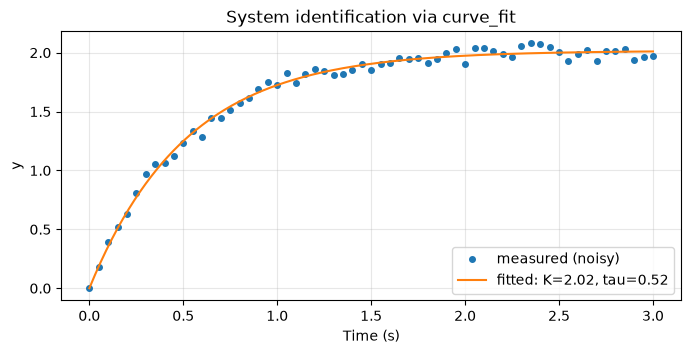

In [9]:
from scipy.optimize import curve_fit

def model(t, K, tau):
    '''一阶环节阶跃响应模型，K 和 tau 是待辨识参数。'''
    return K * (1 - np.exp(-t / tau))

# 造一份「实测数据」：真值 K=2, tau=0.5，加噪声
rng = np.random.default_rng(0)
t_meas = np.linspace(0, 3, 61)
y_meas = model(t_meas, 2.0, 0.5) + rng.normal(0, 0.05, size=t_meas.shape)

popt, pcov = curve_fit(model, t_meas, y_meas, p0=[1.0, 1.0])   # p0: 初值猜测
K_hat, tau_hat = popt
perr = np.sqrt(np.diag(pcov))                                   # 参数标准差
print(f"辨识结果: K = {K_hat:.3f} ± {perr[0]:.3f} (真值 2.0)")
print(f"         tau = {tau_hat:.3f} ± {perr[1]:.3f} (真值 0.5)")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(t_meas, y_meas, "o", ms=4, label="measured (noisy)")
ax.plot(t_fine, model(t_fine, K_hat, tau_hat), label=f"fitted: K={K_hat:.2f}, tau={tau_hat:.2f}")
ax.set_xlabel("Time (s)"); ax.set_ylabel("y"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("System identification via curve_fit")
plt.show()

## 小结与衔接

- `solve_ivp` 三板斧：写导数函数 → 给区间和初值 → 取 `sol.t / sol.y`；
- 高阶 ODE 一律先**状态空间化**再求解；不同物理系统共用同一套数学；
- 有解析解先对照验证（一阶环节），没有就用物理直觉 sanity check（RLC 稳态电流→0）；
- 线性化适用范围是可以量化的（单摆）；数据密不够靠插值，参数未知靠拟合；
- 记住暗号：「慢得反常 → stiff → `method="Radau"`」。

**下周 B06**：静态图升级为交互图——Plotly 悬浮读数、3D 曲面、动画滑块。

---

## ✏️ 练习

> 规则：先独立完成，再点开折叠的参考答案核对。

**练习 1（★，15 分钟，10 分）——直流电机一阶模型**
直流电机电枢电压 $u$ 到角速度 $\omega$ 近似为一阶环节：$J\dot{\omega} + b\omega = K_t u$（$J=0.01,\ b=0.1,\ K_t=0.05$）。
阶跃电压 $u=10$ V，用 `solve_ivp` 求 $\omega(t)$（0~1 s），求稳态转速并与解析解对照（解析解自己推）。
**交付物**：曲线图 + 稳态值数值/解析对照。

**练习 2（★★，25 分钟，20 分）——阻尼比扫描**
弹簧阻尼系统 $m=1,\ k=4$，固定 $F=1$，对 $c \in \{0.5, 1, 2, 4, 8\}$ 分别仿真，
计算每条曲线的**超调量** $M_p = (\max(x) - x_{ss}) / x_{ss}$（$x_{ss} = F/k$），
画出 $c$-$M_p$ 关系图，并指出临界阻尼对应的 $M_p$。
**交付物**：5 条响应曲线图 + $M_p$ 表格/图。

**练习 3（★★，25 分钟，20 分）——单摆周期 vs 摆角**
对初摆角 $\theta_0 \in [1°, 80°]$（取 20 个值），分别数值求解非线性单摆一个周期的时长
（提示：找 $\theta(t)$ 第一次回到 $\theta_0$ 附近的时刻，或对 $\omega$ 过零计时——
可用 `solve_ivp` 的 `events` 参数检测 $\omega = 0$），
画出「周期比 $T/T_0$ 随摆角」的曲线（$T_0$ 为线性化周期）。
**交付物**：曲线图 + 80° 时的周期比数值（应约 1.07）。

**练习 4（★★，20 分钟，15 分）——辨识你的 RLC**
第 4 节 RLC 仿真的电流数据上加 $\sigma=0.02$ 噪声，当作「实测」；
用 `curve_fit` 拟合模型 $i(t) = A e^{-\alpha t}\sin(\omega_d t + \varphi)$，估计衰减系数 $\alpha$
（理论值 $\alpha = R/(2L) = 1$）。`p0` 初值给不好可能拟合失败——体会一下初值的重要性。
**交付物**：拟合曲线对比图 + $\alpha$ 估计值。

---

<details>
<summary>参考答案（做完再点开）</summary>

**练习 1**：

```python
def motor(t, w, J=0.01, b=0.1, Kt=0.05, u=10.0):
    return [(Kt * u - b * w[0]) / J]
sol = solve_ivp(motor, (0, 1), [0.0], t_eval=np.linspace(0, 1, 500))
w_ss = 0.05 * 10 / 0.1   # 稳态 = Kt*u/b = 5 rad/s
print(sol.y[0][-1], w_ss)
```

**练习 2**：

```python
for c in [0.5, 1, 2, 4, 8]:
    sol = solve_ivp(spring_damper, (0, 15), [0, 0], args=(c,), t_eval=np.linspace(0, 15, 1500))
    x = sol.y[0]; x_ss = 1 / 4
    Mp = max(0.0, (x.max() - x_ss) / x_ss)
    print(f"c={c}: Mp={Mp:.3f}")
# c >= 4（临界/过阻尼）时 Mp = 0；c 越小超调越大
```

**练习 3**（events 版本）：

```python
def omega_zero(t, s):      # 事件：角速度过零
    return s[1]
omega_zero.terminal = False
omega_zero.direction = 1   # 由负到正 = 半个周期点（最低点）

T0 = 2 * np.pi * np.sqrt(9.81 / 9.81)   # 用 g/L
ratios = []
for deg in np.linspace(1, 80, 20):
    s0 = [np.deg2rad(deg), 0.0]
    sol = solve_ivp(pendulum_nl, (0, 4), s0, events=omega_zero, rtol=1e-10, atol=1e-12)
    half_T = sol.t_events[0][0]          # 第一次到最低点 = T/4? 
    # 从最大摆角静止释放：到 omega 反向过零是 T/2
    T = 2 * half_T
    ratios.append(T / (2 * np.pi * np.sqrt(L / g)))
# 80 deg 时 T/T0 ≈ 1.073
```

（注意：从最大摆角释放，$\omega$ 由负到正过零发生在 $t = T/2$，故 $T = 2 t_{event}$。）

**练习 4**：

```python
def damped_sin(t, A, alpha, wd, phi):
    return A * np.exp(-alpha * t) * np.sin(wd * t + phi)

noisy = sol.y[1] + rng.normal(0, 0.02, sol.t.shape)   # 用第4节 sol
popt, _ = curve_fit(damped_sin, sol.t, noisy, p0=[1.0, 1.0, 2.0, 0.0])
print("alpha =", popt[1])   # 应接近 R/(2L) = 1.0
# p0 若给 [1, 10, 50, 0] 这类离谱初值，可能收敛到局部最优或直接失败
```

</details>

---

## 延伸阅读

- [SciPy 官方教程：integrate（solve_ivp）](https://docs.scipy.org/doc/scipy/tutorial/integrate.html)
- [`solve_ivp` API 文档（events / dense_output / 求解器选择）](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html)
- [SciPy 教程：interpolate](https://docs.scipy.org/doc/scipy/tutorial/interpolate.html) 与 [optimize.curve_fit](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html)
- 背景阅读：Nise《Control Systems Engineering》第 4 章（时域响应）